# PhD-Level Exploratory Analysis of the flAWS CloudTrail Dataset

## 1. Reproducibility, provenance, and research questions

Source: https://summitroute.com/blog/2020/10/09/public_dataset_of_cloudtrail_logs_from_flaws_cloud/  
Archive: https://summitroute.com/downloads/flaws_cloudtrail_logs.tar

The publisher reports 1,939,207 events from 2017-02-12 through 2020-10-07, 9,402 anonymized source IPs, 8,811 user agents, and 1,242 attempted APIs. IPs and account identifiers were anonymized; object-level S3/Lambda data events were not enabled. Therefore, IP geolocation, reputation lookups, attack attribution, and conclusions about object access are invalid for this dataset.

Primary questions: (1) Is the dataset internally complete and consistent? (2) Which identities, services, APIs, errors, clients, and temporal patterns dominate? (3) Which rare, bursty, privilege-changing, or control-plane-tampering patterns deserve review? (4) How can defensible features and provisional labels be created without leakage? (5) How severe is temporal distribution shift?

In [1]:
# Install only missing packages. Restart the kernel if your environment requests it.
import importlib.util, subprocess, sys
required = {
    'requests': 'requests', 'tqdm': 'tqdm', 'ijson': 'ijson',
    'pyarrow': 'pyarrow', 'duckdb': 'duckdb', 'pandas': 'pandas',
    'numpy': 'numpy', 'matplotlib': 'matplotlib', 'seaborn': 'seaborn',
    'sklearn': 'scikit-learn'
}
missing = [pip_name for module, pip_name in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Environment ready; newly installed:', missing or 'nothing')

Environment ready; newly installed: nothing


In [2]:
from __future__ import annotations
import collections, datetime as dt, gzip, hashlib, json, math, os, platform, re, shutil, tarfile, time, warnings
from pathlib import Path
from typing import Any, Iterable
import duckdb, ijson, matplotlib.pyplot as plt, numpy as np, pandas as pd, pyarrow as pa, pyarrow.parquet as pq, requests, seaborn as sns
from IPython.display import display, Markdown
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from tqdm.auto import tqdm
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100); pd.set_option('display.max_colwidth', 180)
sns.set_theme(style='whitegrid', context='notebook'); np.random.seed(42)
print({'python': platform.python_version(), 'duckdb': duckdb.__version__, 'pandas': pd.__version__, 'pyarrow': pa.__version__})

{'python': '3.10.21', 'duckdb': '1.5.5', 'pandas': '2.3.3', 'pyarrow': '22.0.0'}


E:\Anaconda\envs\cloudtrail\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuration: use QUICK_MODE=True for a fast smoke test, then rerun with False for final results.
PROJECT_DIR = Path.cwd() / 'cloudtrail_eda_workspace'
DOWNLOAD_DIR = PROJECT_DIR / 'downloads'; RAW_DIR = PROJECT_DIR / 'raw'; PARQUET_DIR = PROJECT_DIR / 'parquet_events'; OUTPUT_DIR = PROJECT_DIR / 'outputs'
for p in [DOWNLOAD_DIR, RAW_DIR, PARQUET_DIR, OUTPUT_DIR]: p.mkdir(parents=True, exist_ok=True)
DATA_URL = 'https://summitroute.com/downloads/flaws_cloudtrail_logs.tar'
ARCHIVE_PATH = DOWNLOAD_DIR / 'flaws_cloudtrail_logs.tar'
EXPECTED_MD5 = '4f0481c6be700ffc7610dbbf8cee5578'  # independently published; warn rather than fail if changed
EXPECTED_EVENTS = 1_939_207
QUICK_MODE = False
PARQUET_DIR = PROJECT_DIR / ('parquet_events_quick' if QUICK_MODE else 'parquet_events_full')
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
QUICK_MAX_FILES = 1
QUICK_MAX_RECORDS = 100_000
BATCH_SIZE = 25_000
FORCE_REBUILD_PARQUET = False
print('Workspace:', PROJECT_DIR.resolve())

Workspace: E:\Trash\MLOPS\cloudtrail_eda_workspace


## 2. Download and integrity checks

In [4]:
def download_resumable(url: str, destination: Path, chunk_size: int = 2**20) -> Path:
    if destination.exists() and destination.stat().st_size > 0:
        print(f'Using existing archive: {destination} ({destination.stat().st_size/2**20:.1f} MiB)')
        return destination
    partial = destination.with_suffix(destination.suffix + '.part')
    start = partial.stat().st_size if partial.exists() else 0
    headers = {'Range': f'bytes={start}-'} if start else {}
    with requests.get(url, stream=True, timeout=(30, 300), headers=headers) as r:
        r.raise_for_status()
        resumed = start > 0 and r.status_code == 206
        if start and not resumed:
            start = 0
        mode = 'ab' if resumed else 'wb'
        total = start + int(r.headers.get('Content-Length', 0))
        with open(partial, mode) as f, tqdm(total=total or None, initial=start, unit='B', unit_scale=True, desc='Downloading') as bar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk); bar.update(len(chunk))
    partial.replace(destination)
    return destination

def file_hash(path: Path, algorithm: str = 'md5', block_size: int = 2**20) -> str:
    h = hashlib.new(algorithm)
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(block_size), b''): h.update(block)
    return h.hexdigest()

download_resumable(DATA_URL, ARCHIVE_PATH)
archive_md5 = file_hash(ARCHIVE_PATH)
print({'bytes': ARCHIVE_PATH.stat().st_size, 'MiB': round(ARCHIVE_PATH.stat().st_size/2**20, 2), 'md5': archive_md5})
if EXPECTED_MD5 and archive_md5 != EXPECTED_MD5:
    warnings.warn('Archive MD5 differs from the independently published value. Verify provenance before publication.')

Downloading: 100%|██████████| 252M/252M [02:53<00:00, 1.45MB/s] 


{'bytes': 251688960, 'MiB': 240.03, 'md5': '4f0481c6be700ffc7610dbbf8cee5578'}


## 3. Safely inspect and extract the tar archive

In [5]:
def safe_extract_tar(archive: Path, destination: Path) -> list[str]:
    destination = destination.resolve()
    with tarfile.open(archive, 'r:*') as tf:
        members = tf.getmembers()
        for m in members:
            target = (destination / m.name).resolve()
            if destination not in target.parents and target != destination:
                raise ValueError(f'Unsafe traversal path in archive: {m.name}')
            if m.issym() or m.islnk():
                raise ValueError(f'Links are not extracted: {m.name}')
        tf.extractall(destination, members=members)
        return [m.name for m in members if m.isfile()]

with tarfile.open(ARCHIVE_PATH, 'r:*') as tf:
    members = tf.getmembers()
    inventory = pd.DataFrame([{
        'name': m.name, 'size_MiB': m.size/2**20, 'type': 'file' if m.isfile() else 'directory'
    } for m in members])
display(inventory.head(20)); print('Archive members:', len(inventory), 'Uncompressed GiB:', round(inventory.size_MiB.sum()/1024, 2))
if not any(RAW_DIR.rglob('*.json*')):
    extracted = safe_extract_tar(ARCHIVE_PATH, RAW_DIR)
    print('Extracted files:', len(extracted))
else:
    print('Reusing existing extracted data.')

,name,size_MiB,type
0,flaws_cloudtrail_logs,0.000000,directory
1,flaws_cloudtrail_logs/flaws_cloudtrail00.json.gz,18.320821,file
2,flaws_cloudtrail_logs/flaws_cloudtrail01.json.gz,13.795671,file
3,flaws_cloudtrail_logs/flaws_cloudtrail02.json.gz,9.574857,file
4,flaws_cloudtrail_logs/flaws_cloudtrail03.json.gz,7.442824,file
5,flaws_cloudtrail_logs/flaws_cloudtrail04.json.gz,10.661279,file
6,flaws_cloudtrail_logs/flaws_cloudtrail05.json.gz,11.083474,file
7,flaws_cloudtrail_logs/flaws_cloudtrail06.json.gz,9.817673,file
8,flaws_cloudtrail_logs/flaws_cloudtrail07.json.gz,9.884691,file
9,flaws_cloudtrail_logs/flaws_cloudtrail08.json.gz,11.965329,file


Archive members: 21 Uncompressed GiB: 0.23
Extracted files: 20


In [6]:
log_files = sorted({*RAW_DIR.rglob('*.json.gz'), *RAW_DIR.rglob('*.json')})
if not log_files:
    raise FileNotFoundError(f'No .json or .json.gz logs found under {RAW_DIR}')
file_inventory = pd.DataFrame({'path': [str(p.relative_to(RAW_DIR)) for p in log_files], 'MiB': [p.stat().st_size/2**20 for p in log_files]})
display(file_inventory); print('Compressed/on-disk total MiB:', file_inventory.MiB.sum())
analysis_files = log_files[:QUICK_MAX_FILES] if QUICK_MODE else log_files
print(f'Files selected: {len(analysis_files)} of {len(log_files)}; QUICK_MODE={QUICK_MODE}')

,path,MiB
0,flaws_cloudtrail_logs\flaws_cloudtrail00.json.gz,18.320821
1,flaws_cloudtrail_logs\flaws_cloudtrail01.json.gz,13.795671
2,flaws_cloudtrail_logs\flaws_cloudtrail02.json.gz,9.574857
3,flaws_cloudtrail_logs\flaws_cloudtrail03.json.gz,7.442824
4,flaws_cloudtrail_logs\flaws_cloudtrail04.json.gz,10.661279
5,flaws_cloudtrail_logs\flaws_cloudtrail05.json.gz,11.083474
6,flaws_cloudtrail_logs\flaws_cloudtrail06.json.gz,9.817673
7,flaws_cloudtrail_logs\flaws_cloudtrail07.json.gz,9.884691
8,flaws_cloudtrail_logs\flaws_cloudtrail08.json.gz,11.965329
9,flaws_cloudtrail_logs\flaws_cloudtrail09.json.gz,10.469384


Compressed/on-disk total MiB: 240.0113925933838
Files selected: 20 of 20; QUICK_MODE=False


## 4. Streaming parse and typed Parquet conversion

In [7]:
def dig(obj: dict, path: str, default=None):
    cur: Any = obj
    for key in path.split('.'):
        if not isinstance(cur, dict) or key not in cur: return default
        cur = cur[key]
    return cur

def canonical_json(value: Any) -> str | None:
    if value is None: return None
    return json.dumps(value, sort_keys=True, separators=(',', ':'), default=str)

def to_bool(value: Any):
    if isinstance(value, bool): return value
    if isinstance(value, str) and value.lower() in {'true', 'false'}: return value.lower() == 'true'
    return None

def normalize_event(e: dict, source_file: str, source_record_index: int) -> dict:
    actor_id = (dig(e, 'userIdentity.arn') or dig(e, 'userIdentity.principalId') or
                dig(e, 'userIdentity.accessKeyId') or e.get('sourceIPAddress') or 'UNKNOWN')
    return {
        'source_file': source_file, 'source_record_index': source_record_index,
        'event_time': e.get('eventTime'), 'event_version': e.get('eventVersion'),
        'event_source': e.get('eventSource'), 'event_name': e.get('eventName'),
        'aws_region': e.get('awsRegion'), 'source_ip': e.get('sourceIPAddress'), 'user_agent': e.get('userAgent'),
        'error_code': e.get('errorCode'), 'error_message': e.get('errorMessage'),
        'request_id': e.get('requestID'), 'event_id': e.get('eventID'), 'event_type': e.get('eventType'),
        'api_version': e.get('apiVersion'), 'recipient_account_id': e.get('recipientAccountId'),
        'shared_event_id': e.get('sharedEventID'), 'vpc_endpoint_id': e.get('vpcEndpointId'),
        'management_event': to_bool(e.get('managementEvent')), 'read_only': to_bool(e.get('readOnly')),
        'event_category': e.get('eventCategory'),
        'identity_type': dig(e, 'userIdentity.type'), 'principal_id': dig(e, 'userIdentity.principalId'),
        'identity_arn': dig(e, 'userIdentity.arn'), 'account_id': dig(e, 'userIdentity.accountId'),
        'access_key_id': dig(e, 'userIdentity.accessKeyId'), 'user_name': dig(e, 'userIdentity.userName'),
        'session_issuer_type': dig(e, 'userIdentity.sessionContext.sessionIssuer.type'),
        'session_issuer_principal_id': dig(e, 'userIdentity.sessionContext.sessionIssuer.principalId'),
        'session_issuer_arn': dig(e, 'userIdentity.sessionContext.sessionIssuer.arn'),
        'session_issuer_user_name': dig(e, 'userIdentity.sessionContext.sessionIssuer.userName'),
        'mfa_authenticated': to_bool(dig(e, 'userIdentity.sessionContext.attributes.mfaAuthenticated')),
        'session_creation_date': dig(e, 'userIdentity.sessionContext.attributes.creationDate'),
        'invoked_by': dig(e, 'userIdentity.invokedBy'), 'actor_id': str(actor_id),
        'request_parameters_json': canonical_json(e.get('requestParameters')),
        'response_elements_json': canonical_json(e.get('responseElements')),
        'additional_event_data_json': canonical_json(e.get('additionalEventData')),
        'resources_json': canonical_json(e.get('resources')), 'tls_details_json': canonical_json(e.get('tlsDetails'))
    }

STRING_COLUMNS = [k for k, v in normalize_event({}, '', 0).items() if k not in {'source_record_index','management_event','read_only','mfa_authenticated','event_time'}]
BOOL_COLUMNS = ['management_event','read_only','mfa_authenticated']
def typed_frame(records: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame.from_records(records)
    df['event_time'] = pd.to_datetime(df['event_time'], utc=True, errors='coerce')
    df['source_record_index'] = pd.to_numeric(df['source_record_index'], errors='coerce').astype('Int64')
    for c in STRING_COLUMNS: df[c] = df[c].astype('string')
    for c in BOOL_COLUMNS: df[c] = df[c].astype('boolean')
    return df

In [8]:
def event_iterator(path: Path) -> Iterable[dict]:
    opener = gzip.open if path.suffix == '.gz' else open
    with opener(path, 'rb') as f:
        yield from ijson.items(f, 'Records.item')

def build_parquet(files: list[Path], output_dir: Path, batch_size: int = 25_000, max_records: int | None = None):
    if FORCE_REBUILD_PARQUET and output_dir.exists(): shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    existing = sorted(output_dir.glob('part-*.parquet'))
    if existing and not FORCE_REBUILD_PARQUET:
        print(f'Reusing {len(existing)} Parquet parts. Set FORCE_REBUILD_PARQUET=True to rebuild.')
        return
    batch, total, part = [], 0, 0
    for path in files:
        rel = str(path.relative_to(RAW_DIR))
        for idx, event in enumerate(tqdm(event_iterator(path), desc=rel, unit='events')):
            batch.append(normalize_event(event, rel, idx)); total += 1
            if len(batch) >= batch_size:
                pq.write_table(pa.Table.from_pandas(typed_frame(batch), preserve_index=False), output_dir/f'part-{part:05d}.parquet', compression='zstd')
                batch.clear(); part += 1
            if max_records is not None and total >= max_records: break
        if max_records is not None and total >= max_records: break
    if batch:
        pq.write_table(pa.Table.from_pandas(typed_frame(batch), preserve_index=False), output_dir/f'part-{part:05d}.parquet', compression='zstd')
    print(f'Wrote {total:,} records in {part + bool(batch):,} Parquet parts.')

build_parquet(analysis_files, PARQUET_DIR, BATCH_SIZE, QUICK_MAX_RECORDS if QUICK_MODE else None)
parquet_files = sorted(PARQUET_DIR.glob('part-*.parquet'))
assert parquet_files, 'Parquet conversion produced no files.'
print('Parquet parts:', len(parquet_files), 'size MiB:', round(sum(p.stat().st_size for p in parquet_files)/2**20, 2))

flaws_cloudtrail_logs\flaws_cloudtrail00.json.gz: 100000events [00:23, 4185.97events/s]
flaws_cloudtrail_logs\flaws_cloudtrail01.json.gz: 100000events [00:22, 4470.67events/s]
flaws_cloudtrail_logs\flaws_cloudtrail02.json.gz: 100000events [00:21, 4592.23events/s]
flaws_cloudtrail_logs\flaws_cloudtrail03.json.gz: 100000events [00:24, 4144.38events/s]
flaws_cloudtrail_logs\flaws_cloudtrail04.json.gz: 100000events [00:36, 2735.13events/s]
flaws_cloudtrail_logs\flaws_cloudtrail05.json.gz: 100000events [00:36, 2748.30events/s]
flaws_cloudtrail_logs\flaws_cloudtrail06.json.gz: 100000events [00:36, 2770.26events/s]
flaws_cloudtrail_logs\flaws_cloudtrail07.json.gz: 100000events [00:36, 2723.85events/s]
flaws_cloudtrail_logs\flaws_cloudtrail08.json.gz: 100000events [00:36, 2705.83events/s]
flaws_cloudtrail_logs\flaws_cloudtrail09.json.gz: 100000events [00:36, 2736.42events/s]
flaws_cloudtrail_logs\flaws_cloudtrail10.json.gz: 100000events [00:38, 2579.68events/s]
flaws_cloudtrail_logs\flaws_clou

Wrote 1,939,207 records in 78 Parquet parts.
Parquet parts: 78 size MiB: 213.89


## 5. Analytical database and validity gates

In [9]:
con = duckdb.connect(str(PROJECT_DIR/'cloudtrail_eda.duckdb'))
parquet_glob = str(PARQUET_DIR/'part-*.parquet').replace("'", "''")
con.execute(f"CREATE OR REPLACE VIEW events AS SELECT * FROM read_parquet('{parquet_glob}', union_by_name=true)")
overview = con.sql('''
SELECT count(*) AS events, min(event_time) AS start_time, max(event_time) AS end_time,
       count(DISTINCT event_id) AS unique_event_ids, count(DISTINCT source_ip) AS unique_source_ips,
       count(DISTINCT user_agent) AS unique_user_agents, count(DISTINCT event_name) AS unique_event_names,
       count(DISTINCT event_source) AS unique_services, count(DISTINCT actor_id) AS unique_actors
FROM events
''').df()
display(overview.T)
assert overview.loc[0, 'events'] > 0
assert overview.loc[0, 'start_time'] <= overview.loc[0, 'end_time']
if not QUICK_MODE:
    if overview.loc[0, 'events'] != EXPECTED_EVENTS:
        warnings.warn(f"Expected {EXPECTED_EVENTS:,} publisher-reported events; parsed {overview.loc[0, 'events']:,}. Investigate files/parser.")
    assert overview.loc[0, 'start_time'].year <= 2017 and overview.loc[0, 'end_time'].year >= 2020
display(con.sql('SELECT * FROM events USING SAMPLE 8 ROWS').df())

,0
events,1939207
start_time,2017-02-13 01:27:06+05:30
end_time,2020-10-08 02:33:30+05:30
unique_event_ids,1225784
unique_source_ips,9402
unique_user_agents,8811
unique_event_names,1242
unique_services,164
unique_actors,185


,source_file,source_record_index,event_time,event_version,event_source,event_name,aws_region,source_ip,user_agent,error_code,error_message,request_id,event_id,event_type,api_version,recipient_account_id,shared_event_id,vpc_endpoint_id,management_event,read_only,event_category,identity_type,principal_id,identity_arn,account_id,access_key_id,user_name,session_issuer_type,session_issuer_principal_id,session_issuer_arn,session_issuer_user_name,mfa_authenticated,session_creation_date,invoked_by,actor_id,request_parameters_json,response_elements_json,additional_event_data_json,resources_json,tls_details_json
0,flaws_cloudtrail_logs\flaws_cloudtrail00.json.gz,5553,2017-02-27 05:38:18+05:30,1.04,apigateway.amazonaws.com,GetResources,us-west-2,255.253.125.115,console.amazonaws.com,None,None,d7a92a6b-fc80-11e6-980e-edd6aa4d2f97,bf490e68-8e64-4685-a91e-d8b23cfe6aa6,AwsApiCall,None,811596193553,None,None,<NA>,True,None,Root,811596193553,arn:aws:iam::811596193553:root,811596193553,ASIAPE04PSUZQ2PVMJ7J,None,None,None,None,None,True,2017-02-26T17:48:22Z,None,arn:aws:iam::811596193553:root,"{""restApiId"":""1ga7h020z2"",""template"":false}",None,None,None,None
1,flaws_cloudtrail_logs\flaws_cloudtrail00.json.gz,6810,2017-02-28 13:23:49+05:30,1.02,iam.amazonaws.com,ListRoles,us-east-1,137.53.124.9,aws-cli/1.11.56 Python/2.7.10 Darwin/16.4.0 botocore/1.5.19,None,None,0a6177c2-fd8b-11e6-9f73-75eb302746ae2,821516c78-169d-408f-9c1f-9768c1a65807,AwsApiCall,None,811596193553,None,None,<NA>,<NA>,None,IAMUser,AIDADO2GQD0K8TEF7KW1V,arn:aws:iam::811596193553:user/Level6,811596193553,AKIA3Z2XBVUDFQ9TU4MD,Level6,None,None,None,None,<NA>,None,None,arn:aws:iam::811596193553:user/Level6,None,None,None,None,None
2,flaws_cloudtrail_logs\flaws_cloudtrail01.json.gz,3570,2018-04-18 00:31:48+05:30,1.05,ec2.amazonaws.com,DescribeInstances,ap-southeast-2,155.63.17.217,Boto3/1.7.4 Python/2.7.12 Linux/4.4.0-119-generic Botocore/1.10.4,None,None,05a49ac6-4058-4431-8270-83eb4f492a33,5654bb07-5203-410c-80e2-e8510b6df9ed,AwsApiCall,None,811596193553,None,None,<NA>,<NA>,None,IAMUser,AIDA9BO36HFBHKGJAO9C1,arn:aws:iam::811596193553:user/backup,811596193553,AKIA01U43UX3RBRDXF4Q,backup,None,None,None,None,<NA>,None,None,arn:aws:iam::811596193553:user/backup,"{""filterSet"":{},""instancesSet"":{}}",None,None,None,None
3,flaws_cloudtrail_logs\flaws_cloudtrail01.json.gz,6549,2018-04-18 05:22:32+05:30,1.05,ec2.amazonaws.com,DescribeInstances,ap-south-1,155.63.17.217,Boto3/1.7.4 Python/2.7.12 Linux/4.4.0-119-generic Botocore/1.10.4,None,None,e2837d3d-b0da-42d1-bd00-602ff56e49c8,4c29a519-0e5e-4d39-895f-3f3a25ffc609,AwsApiCall,None,811596193553,None,None,<NA>,<NA>,None,IAMUser,AIDA9BO36HFBHKGJAO9C1,arn:aws:iam::811596193553:user/backup,811596193553,AKIA01U43UX3RBRDXF4Q,backup,None,None,None,None,<NA>,None,None,arn:aws:iam::811596193553:user/backup,"{""filterSet"":{},""instancesSet"":{}}",None,None,None,None
4,flaws_cloudtrail_logs\flaws_cloudtrail01.json.gz,75208,2018-10-29 00:36:44+05:30,1.05,sts.amazonaws.com,AssumeRole,us-east-1,253.0.255.253,aws-sdk-java/1.11.301 Linux/4.9.93-linuxkit-aufs Java_HotSpot(TM)_64-Bit_Server_VM/25.172-b11 java/1.8.0_172,AccessDenied,User: arn:aws:iam::811596193553:user/backup is not authorized to perform: sts:AssumeRole on resource: arn:aws:iam::563230777126:role/VGSCrossAccountSignIn,9c69aced-dae4-11e8-8534-ade2e90cdd42,08488bf8-103d-470c-9d52-0c044a40019d,AwsApiCall,None,811596193553,None,None,<NA>,<NA>,None,IAMUser,AIDA9BO36HFBHKGJAO9C1,arn:aws:iam::811596193553:user/backup,811596193553,AKIA01U43UX3RBRDXF4Q,backup,None,None,None,None,<NA>,None,None,arn:aws:iam::811596193553:user/backup,None,None,None,None,None
5,flaws_cloudtrail_logs\flaws_cloudtrail01.json.gz,78142,2018-10-29 02:24:28+05:30,1.05,sts.amazonaws.com,AssumeRole,us-east-1,253.0.255.253,aws-sdk-java/1.11.301 Linux/4.9.93-linuxkit-aufs Java_HotSpot(TM)_64-Bit_Server_VM/25.172-b11 java/1.8.0_172,AccessDenied,User: arn:aws:iam::811596193553:user/backup is not authorized to perform: sts:Assu

## 6. Data quality, missingness, uniqueness, and duplicate structure

In [10]:
quality = con.sql('''
SELECT
 count(*) AS n, count_if(event_time IS NULL) AS bad_timestamp, count_if(event_id IS NULL) AS missing_event_id,
 count_if(event_source IS NULL) AS missing_source, count_if(event_name IS NULL) AS missing_name,
 count_if(source_ip IS NULL) AS missing_ip, count_if(user_agent IS NULL) AS missing_user_agent,
 count_if(identity_type IS NULL) AS missing_identity_type, count_if(actor_id='UNKNOWN') AS unknown_actor,
 count(*)-count(DISTINCT event_id) AS duplicate_event_id_rows
FROM events
''').df()
display(quality.T)
columns = con.sql('DESCRIBE events').df().column_name.tolist()
missing_union = ' UNION ALL '.join([f"SELECT '{c}' AS column_name, count_if(\"{c}\" IS NULL) AS missing, approx_count_distinct(\"{c}\") AS approx_unique FROM events" for c in columns])
missingness = con.sql(f'SELECT *, missing/(SELECT count(*) FROM events) AS missing_rate FROM ({missing_union}) ORDER BY missing_rate DESC').df()
display(missingness)

,0
n,1939207.0
bad_timestamp,0.0
missing_event_id,0.0
missing_source,0.0
missing_name,0.0
missing_ip,0.0
missing_user_agent,1.0
missing_identity_type,1.0
unknown_actor,0.0
duplicate_event_id_rows,713423.0


,column_name,missing,approx_unique,missing_rate
0,tls_details_json,1939207.0,0,1.000000e+00
1,event_category,1938764.0,1,9.997716e-01
2,vpc_endpoint_id,1938490.0,24,9.996303e-01
3,management_event,1935585.0,1,9.981322e-01
4,api_version,1923344.0,27,9.918199e-01
5,session_issuer_user_name,1896892.0,13,9.781792e-01
6,session_issuer_arn,1896892.0,16,9.781792e-01
7,session_issuer_principal_id,1896892.0,17,9.781792e-01
8,session_issuer_type,1896892.0,1,9.781792e-01
9,read_only,1885894.0,2,9.725078e-01


In [11]:
duplicate_ids = con.sql('''
SELECT event_id, count(*) AS copies, count(DISTINCT source_file) AS files, min(event_time) AS first_seen, max(event_time) AS last_seen
FROM events WHERE event_id IS NOT NULL GROUP BY event_id HAVING count(*) > 1 ORDER BY copies DESC LIMIT 25
''').df()
display(duplicate_ids)
schema_drift = con.sql('''
SELECT date_trunc('month', event_time) AS month, event_version, event_type, event_category,
       count(*) AS events, count_if(management_event IS NULL) AS management_flag_missing,
       count_if(read_only IS NULL) AS readonly_flag_missing
FROM events GROUP BY ALL ORDER BY month, events DESC
''').df()
display(schema_drift.head(30))

,event_id,copies,files,first_seen,last_seen
0,213c3a36-b247-4d26-a44c-44558ce8cd82,8,1,2019-10-16 22:07:51+05:30,2019-10-16 22:07:51+05:30
1,a2812b8d-efab-4073-93a3-b64b440937d,8,1,2019-10-16 22:07:01+05:30,2019-10-16 22:07:01+05:30
2,8e73b14d-4072-42b8-b87d-1d4a656c9831,6,1,2019-04-30 10:30:31+05:30,2019-04-30 10:30:31+05:30
3,1f729f8d-912e-4136-865f-33eb4c3a9e8a,6,1,2019-04-30 10:31:41+05:30,2019-04-30 10:31:41+05:30
4,ac15ee27-a225-45e0-926d-98385a7cd184,6,1,2019-04-30 10:31:40+05:30,2019-04-30 10:31:40+05:30
5,301025-b2ab-4b8e-ba22-13bd72b8b789,6,1,2019-04-30 10:31:30+05:30,2019-04-30 10:31:30+05:30
6,4cfe88aa-8996-40bd-b619-ce59d32df5a0,6,1,2019-04-30 10:31:36+05:30,2019-04-30 10:31:36+05:30
7,f511160-d6f3-4aa7-b536-a950c3d5279e,6,1,2019-04-30 10:31:34+05:30,2019-04-30 10:31:34+05:30
8,1f3a229c-9f6d-411c-a6cc-9967f1522b6f,6,1,2019-04-30 10:31:38+05:30,2019-04-30 10:31:38+05:30
9,0391fbcc-692b-4c85-946e-35ee98ce5be7,6,1,2019-04-30 10:31:45+05:30,2019-04-30 10:31:45+05:30


,month,event_version,event_type,event_category,events,management_flag_missing,readonly_flag_missing
0,2017-02-01 00:00:00+05:30,1.04,AwsApiCall,None,3270,3270.0,1704.0
1,2017-02-01 00:00:00+05:30,1.05,AwsApiCall,None,2893,2893.0,2852.0
2,2017-02-01 00:00:00+05:30,1.02,AwsApiCall,None,1156,1156.0,1156.0
3,2017-02-01 00:00:00+05:30,1.03,AwsApiCall,None,17,17.0,17.0
4,2017-02-01 00:00:00+05:30,1.05,AwsConsoleSignIn,None,8,8.0,8.0
5,2017-03-01 00:00:00+05:30,1.05,AwsApiCall,None,6420,6420.0,6386.0
6,2017-03-01 00:00:00+05:30,1.04,AwsApiCall,None,2098,2098.0,1906.0
7,2017-03-01 00:00:00+05:30,1.02,AwsApiCall,None,1387,1387.0,1383.0
8,2017-03-01 00:00:00+05:30,1.03,AwsApiCall,None,18,18.0,18.0
9,2017-03-01 00:00:00+05:30,1.05,AwsConsoleSignIn,None,9,9.0,9.0


## 7. Temporal coverage and operational rhythms

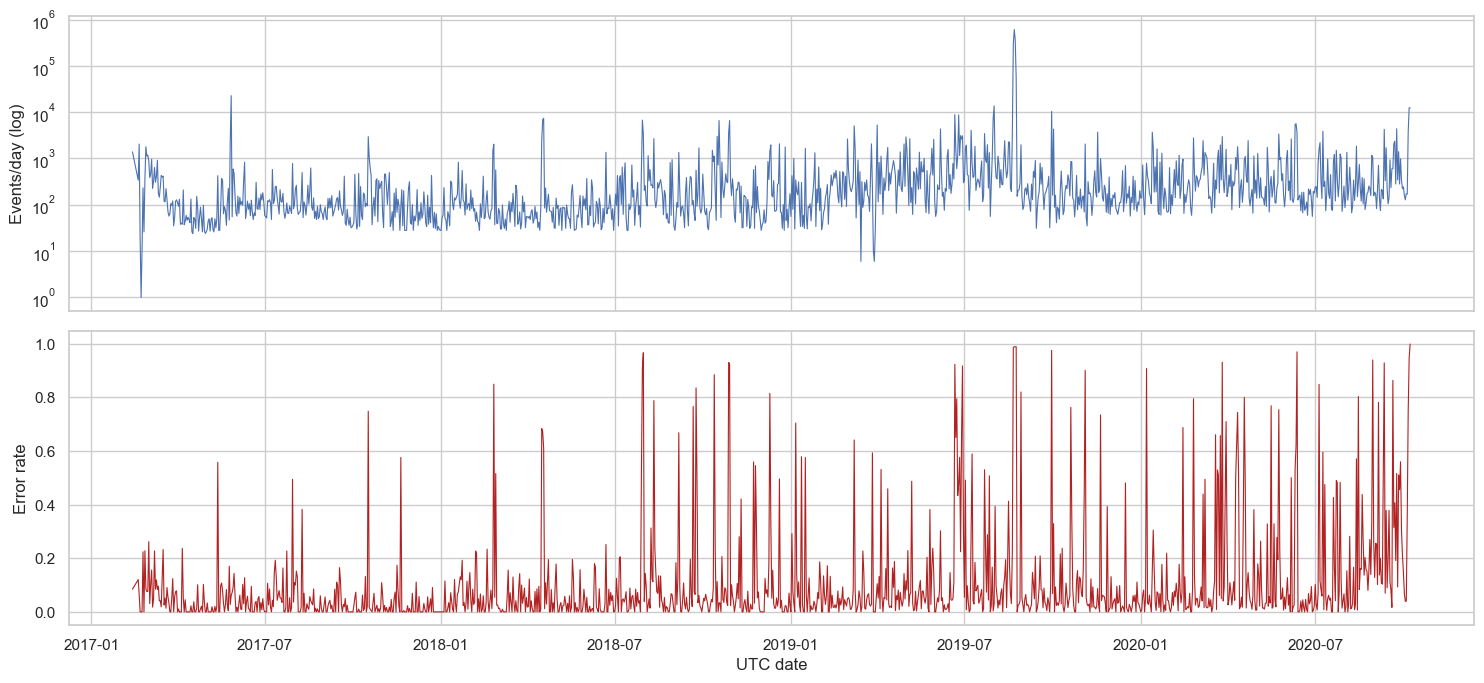

,day,events,errors,actors,error_rate,gap_days
1,2017-02-19,340,41.0,2,0.120588,6.0
771,2019-04-01,5282,554.0,2,0.104885,2.0


In [12]:
daily = con.sql("SELECT CAST(event_time AS DATE) AS day, count(*) AS events, count_if(error_code IS NOT NULL) AS errors, count(DISTINCT actor_id) AS actors FROM events GROUP BY day ORDER BY day").df()
daily['day'] = pd.to_datetime(daily['day']); daily['error_rate'] = daily['errors']/daily['events']
fig, ax = plt.subplots(2,1, figsize=(15,7), sharex=True)
ax[0].plot(daily.day, daily.events, lw=.8); ax[0].set_yscale('log'); ax[0].set_ylabel('Events/day (log)')
ax[1].plot(daily.day, daily.error_rate, lw=.8, color='firebrick'); ax[1].set_ylabel('Error rate'); ax[1].set_xlabel('UTC date')
plt.tight_layout(); plt.show()
gaps = daily.assign(gap_days=daily.day.diff().dt.days).query('gap_days > 1').sort_values('gap_days', ascending=False)
display(gaps.head(20))

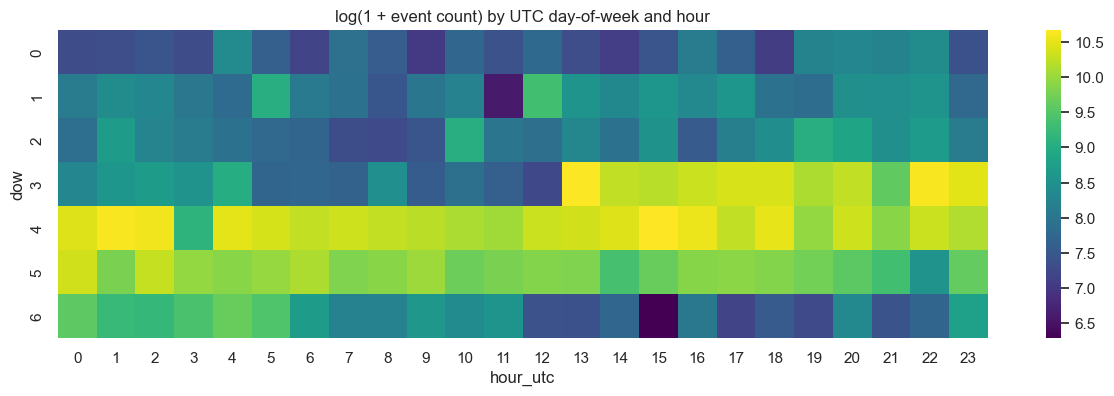

,month,events,apis,actors
21,2018-11-01 00:00:00+05:30,4856,371,8
22,2018-12-01 00:00:00+05:30,10931,343,8
23,2019-01-01 00:00:00+05:30,8296,350,7
24,2019-02-01 00:00:00+05:30,6861,96,12
25,2019-03-01 00:00:00+05:30,17506,366,9
26,2019-04-01 00:00:00+05:30,21222,451,45
27,2019-05-01 00:00:00+05:30,21520,262,8
28,2019-06-01 00:00:00+05:30,42588,303,8
29,2019-07-01 00:00:00+05:30,33214,632,14
30,2019-08-01 00:00:00+05:30,1358472,237,11


In [13]:
hour_dow = con.sql('''
SELECT dayofweek(event_time) AS dow, hour(event_time) AS hour_utc, count(*) AS events
FROM events GROUP BY ALL
''').df().pivot(index='dow', columns='hour_utc', values='events').fillna(0)
plt.figure(figsize=(15,4)); sns.heatmap(np.log1p(hour_dow), cmap='viridis'); plt.title('log(1 + event count) by UTC day-of-week and hour'); plt.show()
monthly = con.sql("SELECT date_trunc('month', event_time) AS month, count(*) AS events, count(DISTINCT event_name) AS apis, count(DISTINCT actor_id) AS actors FROM events GROUP BY month ORDER BY month").df()
display(monthly.tail(24))

## 8. Services, APIs, regions, and long-tail behavior

,event_source,events,apis,error_rate
0,ec2.amazonaws.com,1543250,176,0.872386
1,sts.amazonaws.com,96796,6,0.176030
2,s3.amazonaws.com,87991,35,0.773250
3,iam.amazonaws.com,65991,86,0.128533
4,rds.amazonaws.com,17827,26,0.384249
5,lambda.amazonaws.com,12265,24,0.277864
6,apigateway.amazonaws.com,8680,63,0.480760
7,cloudtrail.amazonaws.com,7993,13,0.156262
8,logs.amazonaws.com,7901,16,0.083660
9,redshift.amazonaws.com,6740,25,0.306528


,event_source,event_name,read_only,events,error_rate,actors
0,ec2.amazonaws.com,RunInstances,False,1323105,0.999998,4
1,ec2.amazonaws.com,DescribeSnapshots,False,102381,0.008849,7
2,sts.amazonaws.com,AssumeRole,False,79322,0.213573,55
3,s3.amazonaws.com,GetBucketAcl,True,23832,0.999580,52
4,ec2.amazonaws.com,DescribeInstances,False,18888,0.019060,10
5,s3.amazonaws.com,GetBucketAcl,False,18819,0.918327,10
6,sts.amazonaws.com,GetCallerIdentity,False,17128,0.000000,6
7,iam.amazonaws.com,GetPolicyVersion,False,14783,0.009132,6
8,s3.amazonaws.com,ListBuckets,False,12961,0.089191,11
9,ec2.amazonaws.com,DescribeSpotPriceHistory,False,10720,0.003358,5


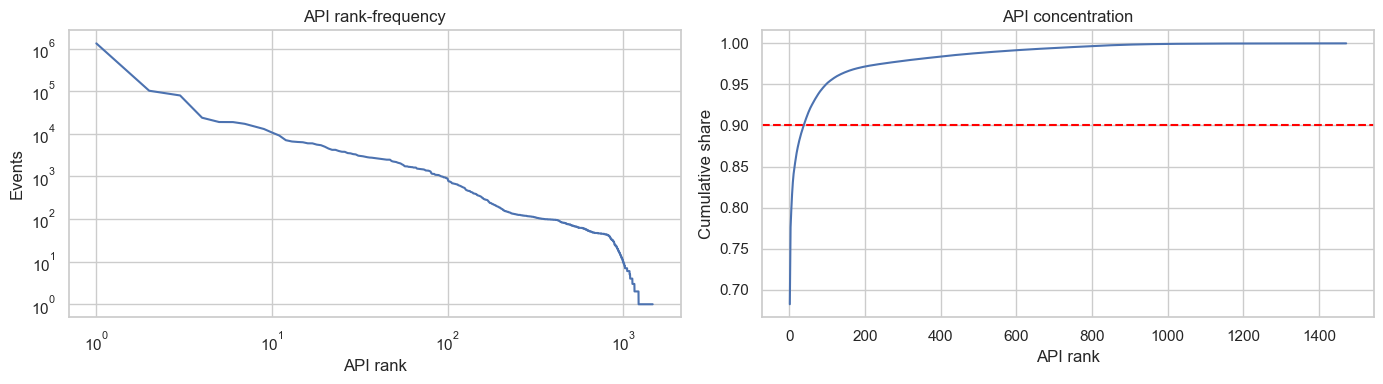

In [14]:
service_counts = con.sql('SELECT event_source, count(*) AS events, count(DISTINCT event_name) AS apis, count_if(error_code IS NOT NULL)/count(*)::DOUBLE AS error_rate FROM events GROUP BY event_source ORDER BY events DESC').df()
api_counts = con.sql('SELECT event_source, event_name, coalesce(read_only, false) AS read_only, count(*) AS events, count_if(error_code IS NOT NULL)/count(*)::DOUBLE AS error_rate, count(DISTINCT actor_id) AS actors FROM events GROUP BY ALL ORDER BY events DESC').df()
display(service_counts.head(30)); display(api_counts.head(50))
api_counts['rank'] = np.arange(1, len(api_counts)+1); api_counts['cumulative_share'] = api_counts.events.cumsum()/api_counts.events.sum()
fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].loglog(api_counts['rank'], api_counts.events); ax[0].set(xlabel='API rank', ylabel='Events', title='API rank-frequency')
ax[1].plot(api_counts['rank'], api_counts.cumulative_share); ax[1].axhline(.9, ls='--', c='red'); ax[1].set(xlabel='API rank', ylabel='Cumulative share', title='API concentration')
plt.tight_layout(); plt.show()

## 9. Identity, root usage, MFA, credential type, and session context

In [15]:
identity_summary = con.sql('''
SELECT coalesce(identity_type, '<NULL>') AS identity_type, coalesce(mfa_authenticated::VARCHAR, '<NULL>') AS mfa,
       count(*) AS events, count(DISTINCT actor_id) AS actors, count_if(error_code IS NOT NULL)/count(*)::DOUBLE AS error_rate,
       count_if(coalesce(read_only, false)=false)/count(*)::DOUBLE AS write_rate
FROM events GROUP BY ALL ORDER BY events DESC
''').df()
display(identity_summary)
root_events = con.sql('''
SELECT event_time, event_source, event_name, source_ip, user_agent, mfa_authenticated, error_code, request_parameters_json
FROM events WHERE lower(coalesce(identity_type,''))='root' OR lower(coalesce(identity_arn,'')) LIKE '%:root'
ORDER BY event_time
''').df()
print('Root-associated events:', len(root_events)); display(root_events.head(50))

,identity_type,mfa,events,actors,error_rate,write_rate
0,IAMUser,<NULL>,1336858,15,0.753676,0.965153
1,IAMUser,false,488751,3,0.976158,0.999826
2,AWSService,<NULL>,57616,45,0.000000,1.000000
3,AssumedRole,false,41476,20,0.491730,0.944088
4,Root,true,8014,1,0.110307,0.791240
5,AWSAccount,<NULL>,2628,72,0.627093,0.533486
6,Root,<NULL>,1629,1,0.002455,0.958257
7,Root,false,1354,1,0.076071,0.991876
8,AssumedRole,true,839,31,0.023838,0.934446
9,IAMUser,true,41,1,0.097561,1.000000


Root-associated events: 10997


,event_time,event_source,event_name,source_ip,user_agent,mfa_authenticated,error_code,request_parameters_json
0,2017-02-13 01:27:06+05:30,s3.amazonaws.com,ListBuckets,255.253.125.115,[S3Console/0.4],False,None,None
1,2017-02-13 01:29:10+05:30,iam.amazonaws.com,GetAccountPasswordPolicy,255.253.125.115,console.amazonaws.com,False,NoSuchEntityException,None
2,2017-02-13 01:29:10+05:30,iam.amazonaws.com,GetAccountSummary,255.253.125.115,console.amazonaws.com,False,None,None
3,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListAccountAliases,255.253.125.115,console.amazonaws.com,False,None,None
4,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListMFADevices,255.253.125.115,console.amazonaws.com,False,None,None
5,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListAccessKeys,255.253.125.115,console.amazonaws.com,False,None,None
6,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListAccessKeys,255.253.125.115,console.amazonaws.com,False,None,None
7,2017-02-13 01:29:10+05:30,iam.amazonaws.com,GetAccountPasswordPolicy,255.253.125.115,console.amazonaws.com,False,NoSuchEntityException,None
8,2017-02-13 01:29:10+05:30,iam.amazonaws.com,GetAccountSummary,255.253.125.115,console.amazonaws.com,False,None,None
9,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListAccountAliases,255.253.125.115,console.amazonaws.com,False,None,None


## 10. Source-IP and user-agent ecology

,source_ip,events,actors,apis,user_agents,error_rate,first_seen,last_seen
0,5.205.62.253,1321919,2,16,3,0.989583,2019-08-21 13:11:17+05:30,2019-08-24 06:19:37+05:30
1,ec2.amazonaws.com,44158,2,3,1,0.000000,2017-02-23 10:38:23+05:30,2020-10-08 02:27:09+05:30
2,255.253.125.115,30197,11,249,42,0.066464,2017-02-13 01:27:06+05:30,2017-07-17 21:50:57+05:30
3,193.29.252.218,23498,1,10,9,0.998894,2019-08-19 00:53:45+05:30,2020-10-08 02:33:30+05:30
4,240.252.161.77,22394,2,79,8,0.150487,2019-06-17 23:20:41+05:30,2019-08-01 03:05:47+05:30
5,0.52.31.206,18774,3,105,9,0.674656,2019-06-14 02:37:30+05:30,2019-08-02 23:15:34+05:30
6,155.63.17.217,15925,1,8,2,0.642512,2018-04-16 12:29:18+05:30,2018-04-18 10:28:49+05:30
7,24.251.252.2,10208,2,12,2,0.992849,2019-09-30 12:06:08+05:30,2019-09-30 13:11:38+05:30
8,251.105.254.1,10106,4,813,11,0.793192,2020-06-10 10:28:48+05:30,2020-06-12 04:25:53+05:30
9,255.171.1.252,9780,3,475,45,0.378528,2020-04-10 20:28:21+05:30,2020-09-22 19:48:26+05:30


,ua_family,events,raw_user_agents,actors,error_rate
0,boto,1634435,607,59,0.897716
1,aws-cli,190298,7883,48,0.105718
2,aws-service,63090,14,29,0.024917
3,other,42915,212,59,0.404497
4,aws-console,7710,24,5,0.140597
5,terraform,462,22,4,0.409091
6,browser,283,48,18,0.466431
7,cloudformation,13,1,1,0.076923
8,missing,1,0,1,0.000000


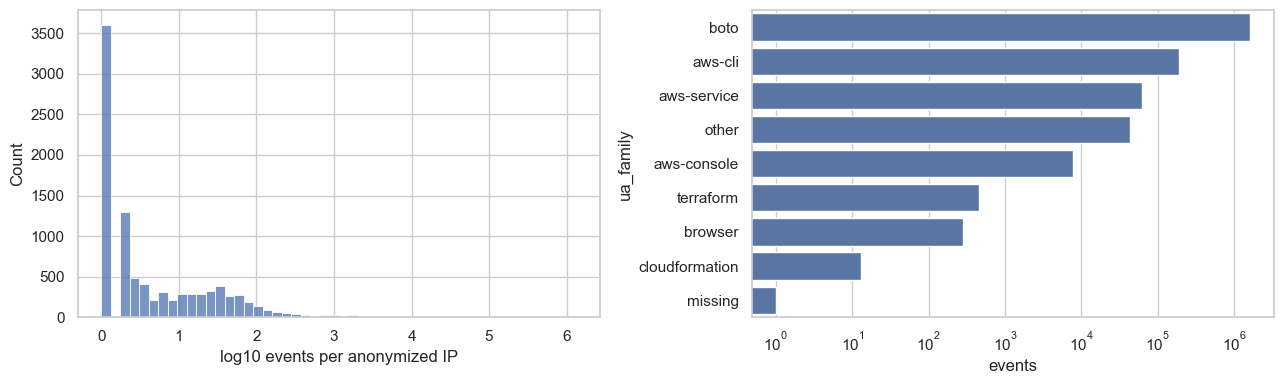

In [16]:
def ua_family_sql(col='user_agent'):
    return f"CASE WHEN {col} IS NULL THEN 'missing' WHEN lower({col}) LIKE '%console%' THEN 'aws-console' WHEN lower({col}) LIKE '%aws-cli%' THEN 'aws-cli' WHEN lower({col}) LIKE '%boto%' THEN 'boto' WHEN lower({col}) LIKE '%botocore%' THEN 'botocore' WHEN lower({col}) LIKE '%terraform%' THEN 'terraform' WHEN lower({col}) LIKE '%cloudformation%' THEN 'cloudformation' WHEN lower({col}) LIKE '%mozilla%' THEN 'browser' WHEN lower({col}) LIKE '%.amazonaws.com%' THEN 'aws-service' ELSE 'other' END"
con.execute(f'CREATE OR REPLACE VIEW events_enriched AS SELECT *, {ua_family_sql()} AS ua_family FROM events')
ip_profile = con.sql('''
SELECT source_ip, count(*) AS events, count(DISTINCT actor_id) AS actors, count(DISTINCT event_name) AS apis,
       count(DISTINCT user_agent) AS user_agents, count_if(error_code IS NOT NULL)/count(*)::DOUBLE AS error_rate,
       min(event_time) AS first_seen, max(event_time) AS last_seen
FROM events_enriched GROUP BY source_ip ORDER BY events DESC
''').df()
ua_profile = con.sql('SELECT ua_family, count(*) AS events, count(DISTINCT user_agent) AS raw_user_agents, count(DISTINCT actor_id) AS actors, count_if(error_code IS NOT NULL)/count(*)::DOUBLE AS error_rate FROM events_enriched GROUP BY ua_family ORDER BY events DESC').df()
display(ip_profile.head(30)); display(ua_profile)
fig, ax = plt.subplots(1,2,figsize=(13,4)); sns.histplot(np.log10(ip_profile.events.clip(lower=1)), bins=50, ax=ax[0]); ax[0].set_xlabel('log10 events per anonymized IP'); sns.barplot(data=ua_profile, y='ua_family', x='events', ax=ax[1]); ax[1].set_xscale('log'); plt.tight_layout(); plt.show()

## 11. Errors, authorization failures, and repeated failure campaigns

In [17]:
errors = con.sql('''
SELECT error_code, event_source, event_name, count(*) AS events, count(DISTINCT actor_id) AS actors, count(DISTINCT source_ip) AS ips
FROM events WHERE error_code IS NOT NULL GROUP BY ALL ORDER BY events DESC
''').df()
display(errors.head(75))
failure_bursts = con.sql('''
SELECT time_bucket(INTERVAL '5 minutes', event_time) AS window_start, actor_id, source_ip,
       count(*) AS failures, count(DISTINCT event_name) AS failed_apis, count(DISTINCT error_code) AS error_types
FROM events WHERE error_code IS NOT NULL GROUP BY ALL HAVING count(*) >= 10 ORDER BY failures DESC LIMIT 100
''').df()
display(failure_bursts)

,error_code,event_source,event_name,events,actors,ips
0,Client.RequestLimitExceeded,ec2.amazonaws.com,RunInstances,778751,2,5
1,Client.UnauthorizedOperation,ec2.amazonaws.com,RunInstances,336397,3,673
2,Client.Unsupported,ec2.amazonaws.com,RunInstances,101226,2,297
3,Server.InsufficientInstanceCapacity,ec2.amazonaws.com,RunInstances,59323,2,9
4,Client.InstanceLimitExceeded,ec2.amazonaws.com,RunInstances,43272,2,5
...,...,...,...,...,...,...
70,AccessDenied,acm.amazonaws.com,ListCertificates,372,5,39
71,AccessDenied,kms.amazonaws.com,ListKeys,310,3,39
72,NoSuchEntityException,iam.amazonaws.com,GetLoginProfile,288,3,75
73,Client.UnauthorizedOperation,ec2.amazonaws.com,CopySnapshot,286,2,147


,window_start,actor_id,source_ip,failures,failed_apis,error_types
0,2019-08-21 13:35:00+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,2644,3,4
1,2019-08-21 13:30:00+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,2614,3,5
2,2019-08-22 04:25:00+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,2566,3,4
3,2019-08-22 05:50:00+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,2508,3,5
4,2019-08-21 13:25:00+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,2486,3,4
...,...,...,...,...,...,...
95,2019-08-22 14:05:00+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,1826,1,6
96,2019-08-21 16:00:00+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,1824,3,5
97,2019-08-22 02:00:00+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,1822,3,4
98,2019-08-23 00:40:00+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,1820,3,6


## 12. Security watchlists and auditable rule signals

In [18]:
WATCHLISTS = {
 'identity_recon': ['GetCallerIdentity','ListUsers','ListRoles','ListAccessKeys','ListAccountAliases','GetAccountAuthorizationDetails'],
 'credential_change': ['CreateAccessKey','UpdateAccessKey','DeleteAccessKey','CreateLoginProfile','UpdateLoginProfile','DeactivateMFADevice','DeleteVirtualMFADevice'],
 'privilege_change': ['AttachUserPolicy','AttachRolePolicy','AttachGroupPolicy','PutUserPolicy','PutRolePolicy','PutGroupPolicy','CreatePolicyVersion','SetDefaultPolicyVersion','AddUserToGroup','UpdateAssumeRolePolicy'],
 's3_discovery_or_policy': ['ListBuckets','GetBucketPolicy','PutBucketPolicy','DeleteBucketPolicy','GetBucketAcl','PutBucketAcl','PutPublicAccessBlock','DeletePublicAccessBlock'],
 'sts_or_federation': ['AssumeRole','AssumeRoleWithSAML','AssumeRoleWithWebIdentity','GetFederationToken'],
 'ec2_security_change': ['AuthorizeSecurityGroupIngress','AuthorizeSecurityGroupEgress','ModifyInstanceAttribute','RunInstances','CreateKeyPair','ImportKeyPair'],
 'kms_change': ['DisableKey','ScheduleKeyDeletion','PutKeyPolicy','CreateGrant','RetireGrant','RevokeGrant'],
 'cloudtrail_tamper': ['StopLogging','DeleteTrail','UpdateTrail','PutEventSelectors','DeleteEventDataStore','UpdateEventDataStore']
}
watch_rows = [(category, api) for category, apis in WATCHLISTS.items() for api in apis]
watch_df = pd.DataFrame(watch_rows, columns=['signal_category','event_name'])
con.register('watchlist', watch_df)
watch_hits = con.sql('''
SELECT w.signal_category, e.event_source, e.event_name, count(*) AS events, count(DISTINCT e.actor_id) AS actors,
       count_if(e.error_code IS NOT NULL)/count(*)::DOUBLE AS error_rate, min(e.event_time) AS first_seen, max(e.event_time) AS last_seen
FROM events e JOIN watchlist w USING(event_name) GROUP BY ALL ORDER BY signal_category, events DESC
''').df()
display(watch_hits)

,signal_category,event_source,event_name,events,actors,error_rate,first_seen,last_seen
0,cloudtrail_tamper,cloudtrail.amazonaws.com,StopLogging,2,1,1.000000,2019-06-07 16:34:25+05:30,2019-06-07 16:34:25+05:30
1,cloudtrail_tamper,cloudtrail.amazonaws.com,DeleteTrail,1,1,0.000000,2019-08-23 21:18:50+05:30,2019-08-23 21:18:50+05:30
2,cloudtrail_tamper,cloudtrail.amazonaws.com,UpdateTrail,1,1,1.000000,2017-08-04 01:20:59+05:30,2017-08-04 01:20:59+05:30
3,credential_change,iam.amazonaws.com,CreateAccessKey,53,5,0.754717,2017-02-13 02:28:27+05:30,2020-09-16 07:03:23+05:30
4,credential_change,iam.amazonaws.com,DeleteAccessKey,22,4,0.454545,2017-02-20 06:53:10+05:30,2020-04-18 20:14:00+05:30
5,credential_change,iam.amazonaws.com,DeleteVirtualMFADevice,7,1,0.000000,2017-07-13 01:55:59+05:30,2019-03-03 22:02:55+05:30
6,credential_change,iam.amazonaws.com,UpdateAccessKey,6,2,0.333333,2017-02-27 11:12:07+05:30,2019-02-24 05:18:21+05:30
7,credential_change,iam.amazonaws.com,CreateLoginProfile,4,3,0.750000,2017-05-16 08:33:57+05:30,2020-03-25 03:50:06+05:30
8,credential_change,iam.amazonaws.com,DeactivateMFADevice,4,1,0.000000,2019-03-03 21:59:30+05:30,2019-03-03 22:02:55+05:30
9,credential_change,iam.amazonaws.com,UpdateLoginProfile,3,3,0.666667,2017-09-17 20:13:04+05:30,2020-03-25 03:51:11+05:30


In [19]:
# Parameter-content indicators. These are string searches over canonical JSON and require manual validation.
parameter_indicators = con.sql(r'''
SELECT event_time, actor_id, source_ip, event_source, event_name, error_code, request_parameters_json,
  CASE
   WHEN lower(coalesce(request_parameters_json,'')) LIKE '%\"effect\":\"allow\"%' AND lower(request_parameters_json) LIKE '%\"principal\":\"*\"%' THEN 'wildcard_principal_allow'
   WHEN lower(coalesce(request_parameters_json,'')) LIKE '%0.0.0.0/0%' THEN 'world_open_cidr'
   WHEN lower(coalesce(request_parameters_json,'')) LIKE '%public-read%' THEN 'public_read_acl'
   WHEN lower(coalesce(request_parameters_json,'')) LIKE '%blockpublicacls%false%' THEN 'public_access_block_disabled'
  END AS indicator
FROM events
WHERE indicator IS NOT NULL
ORDER BY event_time
''').df()
print('Parameter-indicator hits:', len(parameter_indicators)); display(parameter_indicators.head(100))

Parameter-indicator hits: 9


,event_time,actor_id,source_ip,event_source,event_name,error_code,request_parameters_json,indicator
0,2017-09-12 15:11:33+05:30,arn:aws:iam::811596193553:user/backup,192.87.148.239,s3.amazonaws.com,PutBucketAcl,AllAccessDisabled,"{""acl"":[""""],""bucketName"":""BUCKET_NAME"",""x-amz-acl"":[""public-read""]}",public_read_acl
1,2017-09-12 15:13:05+05:30,arn:aws:iam::811596193553:user/backup,192.87.148.239,s3.amazonaws.com,PutBucketAcl,AccessDenied,"{""acl"":[""""],""bucketName"":""archpi.dabase.com"",""x-amz-acl"":[""public-read""]}",public_read_acl
2,2018-11-26 14:45:52+05:30,arn:aws:iam::811596193553:user/backup,5.180.250.254,s3.amazonaws.com,CreateBucket,AccessDenied,"{""CreateBucketConfiguration"":{""LocationConstraint"":""us-west-2"",""xmlns"":""http://s3.amazonaws.com/doc/2006-03-01/""},""bucketName"":""31521bbe9b6346537bb30ddd3ce00b878fe25f0d977b85f6...",public_read_acl
3,2019-04-23 05:38:01+05:30,arn:aws:iam::811596193553:user/backup,173.215.203.26,s3.amazonaws.com,CreateBucket,AccessDenied,"{""bucketName"":""challenge3-1cfdff6d50890ea0d96f7f771998556e.cloud.ctf"",""host"":[""s3.amazonaws.com""],""x-amz-acl"":[""public-read""]}",public_read_acl
4,2019-04-23 05:38:01+05:30,arn:aws:iam::811596193553:user/backup,173.215.203.26,s3.amazonaws.com,CreateBucket,AccessDenied,"{""bucketName"":""challenge3-flag-02ecc82de058fe8c7758856ea266bb6a.cloud.ctf"",""host"":[""s3.amazonaws.com""],""x-amz-acl"":[""public-read""]}",public_read_acl
5,2019-04-23 05:38:01+05:30,arn:aws:iam::811596193553:user/backup,173.215.203.26,s3.amazonaws.com,CreateBucket,AccessDenied,"{""bucketName"":""cloud.ctf"",""host"":[""s3.amazonaws.com""],""x-amz-acl"":[""public-read""]}",public_read_acl
6,2019-04-23 05:38:01+05:30,arn:aws:iam::811596193553:user/backup,173.215.203.26,s3.amazonaws.com,CreateBucket,AccessDenied,"{""bucketName"":""challenge3-1cfdff6d50890ea0d96f7f771998556e.cloud.ctf"",""host"":[""s3.amazonaws.com""],""x-amz-acl"":[""public-read""]}",public_read_acl
7,2019-04-23 05:38:01+05:30,arn:aws:iam::811596193553:user/backup,173.215.203.26,s3.amazonaws.com,CreateBucket,AccessDenied,"{""bucketName"":""challenge3-flag-02ecc82de058fe8c7758856ea266bb6a.cloud.ctf"",""host"":[""s3.amazonaws.com""],""x-amz-acl"":[""public-read""]}",public_read_acl
8,2019-04-23 05:38:01+05:30,arn:aws:iam::811596193553:user/backup,173.215.203.26,s3.amazonaws.com,CreateBucket,AccessDenied,"{""bucketName"":""cloud.ctf"",""host"":[""s3.amazonaws.com""],""x-amz-acl"":[""public-read""]}",public_read_acl


## 13. Actor behavior profiles, concentration, diversity, and burstiness

In [20]:
actor_profiles = con.sql('''
WITH base AS (
 SELECT actor_id, count(*) AS events, count(DISTINCT event_name) AS api_diversity, count(DISTINCT event_source) AS service_diversity,
        count(DISTINCT source_ip) AS ip_diversity, count(DISTINCT user_agent) AS ua_diversity,
        count_if(error_code IS NOT NULL) AS errors, count_if(coalesce(read_only,false)=false) AS writes,
        min(event_time) AS first_seen, max(event_time) AS last_seen
 FROM events GROUP BY actor_id
), api_p AS (
 SELECT actor_id, event_name, count(*)::DOUBLE/sum(count(*)) OVER(PARTITION BY actor_id) AS p FROM events GROUP BY actor_id,event_name
), ent AS (SELECT actor_id, -sum(p*ln(p)) AS api_entropy FROM api_p GROUP BY actor_id)
SELECT b.*, errors/events::DOUBLE AS error_rate, writes/events::DOUBLE AS write_rate,
       date_diff('second', first_seen, last_seen)/3600.0 AS active_span_hours, e.api_entropy
FROM base b LEFT JOIN ent e USING(actor_id) ORDER BY events DESC
''').df()
display(actor_profiles.head(50)); display(actor_profiles.describe(percentiles=[.5,.9,.95,.99,.999]).T)

,actor_id,events,api_diversity,service_diversity,ip_diversity,ua_diversity,errors,writes,first_seen,last_seen,error_rate,write_rate,active_span_hours,api_entropy
0,arn:aws:iam::811596193553:user/backup,915834,1041,159,5293,7760,742447.0,887295.0,2017-02-13 02:45:12+05:30,2020-10-08 02:33:30+05:30,0.810679,0.968838,31991.805000,1.577210
1,arn:aws:iam::811596193553:user/Level6,905082,910,136,1846,2885,742136.0,886956.0,2017-02-27 04:43:33+05:30,2020-10-07 20:22:39+05:30,0.819965,0.979973,31647.651667,1.799934
2,ec2.amazonaws.com,43555,1,1,1,1,0.0,43555.0,2017-02-23 10:38:23+05:30,2020-10-08 02:27:09+05:30,0.000000,1.000000,31743.812778,-0.000000
3,arn:aws:sts::811596193553:assumed-role/flaws/i-aa2d3b42e5c6e801a,17208,726,116,651,893,16517.0,15437.0,2017-02-28 07:54:57+05:30,2020-10-05 21:40:46+05:30,0.959844,0.897083,31573.763611,5.927524
4,arn:aws:sts::811596193553:assumed-role/SecurityMonkey/secmonkey,12354,47,13,2,4,45.0,12214.0,2017-05-27 03:56:49+05:30,2017-05-27 20:45:15+05:30,0.003643,0.988668,16.807222,2.965920
5,arn:aws:iam::811596193553:root,10997,266,31,39,73,991.0,9245.0,2017-02-13 01:27:06+05:30,2020-10-08 00:02:38+05:30,0.090115,0.840684,31990.592222,4.610003
6,config.amazonaws.com,7473,1,1,1,1,0.0,7473.0,2017-05-29 22:05:26+05:30,2020-10-08 01:47:38+05:30,0.000000,1.000000,29451.703333,-0.000000
7,lambda.amazonaws.com,5212,1,1,1,1,0.0,5212.0,2017-02-23 09:39:48+05:30,2020-10-07 20:22:57+05:30,0.000000,1.000000,31738.719167,-0.000000
8,arn:aws:iam::811596193553:user/SecurityMokey,4522,1,1,1,1,53.0,4522.0,2017-05-27 03:55:09+05:30,2017-05-27 20:45:15+05:30,0.011720,1.000000,16.835000,-0.000000
9,arn:aws:sts::811596193553:assumed-role/Level6/Level6,4190,2,1,3482,8,1.0,4190.0,2017-02-27 05:55:39+05:30,2020-10-07 20:23:06+05:30,0.000239,1.000000,31646.457500,0.002229


,count,mean,std,min,50%,90%,95%,99%,99.9%,max
events,185.0,10482.200000,94415.010631,1.0,2.000000,305.800000,4150.600000,181399.320000,913855.632000,915834.000000
api_diversity,185.0,22.627027,124.011817,1.0,1.000000,7.000000,32.600000,755.440000,1016.896000,1041.000000
service_diversity,185.0,4.470270,19.406141,1.0,1.000000,2.000000,5.800000,119.200000,154.768000,159.000000
ip_diversity,185.0,62.864865,484.850658,1.0,1.000000,2.000000,3.800000,2107.760000,4959.776000,5293.000000
ua_diversity,185.0,64.924324,610.568948,0.0,1.000000,2.000000,4.000000,1211.720000,6863.000000,7760.000000
errors,185.0,8149.805405,76966.537312,0.0,1.000000,15.000000,95.800000,132616.040000,742389.776000,742447.000000
writes,185.0,10201.000000,91996.172339,0.0,2.000000,228.600000,4150.600000,178499.160000,887232.624000,887295.000000
error_rate,185.0,0.453014,0.472300,0.0,0.200000,1.000000,1.000000,1.000000,1.000000,1.000000
write_rate,185.0,0.620929,0.467729,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
active_span_hours,185.0,1745.758619,6581.035482,0.0,0.003333,836.855944,11878.115667,31783.297489,31991.581849,31991.805000


,window_start,actor_id,events,api_diversity,service_diversity,ip_diversity,ua_diversity,errors,writes,root_events,root_no_mfa_events,error_rate,write_rate
40174,2019-08-22 12:30:00+05:30,arn:aws:iam::811596193553:user/backup,19700,6,2,1,1,19580.0,19700.0,0.0,0.0,0.993909,1.000000
22750,2019-08-22 12:30:00+05:30,arn:aws:iam::811596193553:user/Level6,19538,31,6,2,3,19334.0,19516.0,0.0,0.0,0.989559,0.998874
8974,2019-08-22 16:30:00+05:30,arn:aws:iam::811596193553:user/Level6,18862,6,2,1,1,18736.0,18862.0,0.0,0.0,0.993320,1.000000
12650,2019-08-22 15:30:00+05:30,arn:aws:iam::811596193553:user/Level6,18594,6,2,1,1,18454.0,18594.0,0.0,0.0,0.992471,1.000000
28878,2019-08-22 00:30:00+05:30,arn:aws:iam::811596193553:user/Level6,17896,15,5,2,3,17686.0,17896.0,0.0,0.0,0.988266,1.000000
36641,2019-08-22 09:30:00+05:30,arn:aws:iam::811596193553:user/Level6,17190,6,2,1,1,17002.0,17190.0,0.0,0.0,0.989063,1.000000
26256,2019-08-22 06:30:00+05:30,arn:aws:iam::811596193553:user/Level6,17190,6,2,1,1,16990.0,17190.0,0.0,0.0,0.988365,1.000000
54347,2019-08-22 16:30:00+05:30,arn:aws:iam::811596193553:user/backup,17160,6,2,1,1,17028.0,17160.0,0.0,0.0,0.992308,1.000000
43719,2019-08-21 23:30:00+05:30,arn:aws:iam::811596193553:user/Level6,16826,6,2,1,1,16682.0,16826.0,0.0,0.0,0.991442,1.000000
29687,2019-08-21 14:30:00+05:30,arn:aws:iam::811596193553:user/Level6,16626,10,4,2,3,16428.0,16626.0,0.0,0.0,0.988091,1.000000


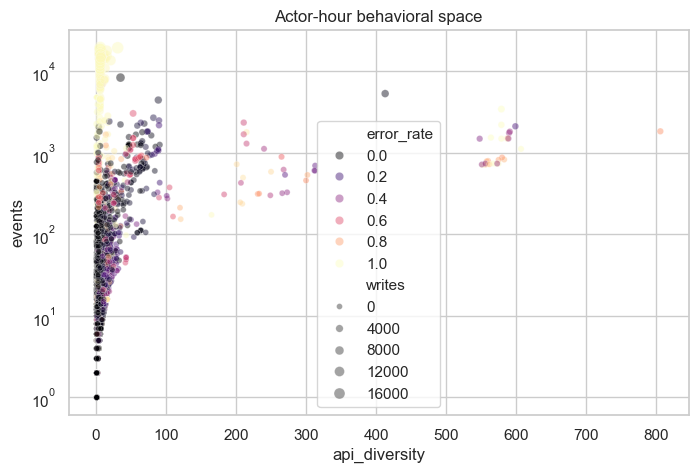

In [21]:
actor_windows = con.sql('''
SELECT time_bucket(INTERVAL '1 hour', event_time) AS window_start, actor_id,
 count(*) AS events, count(DISTINCT event_name) AS api_diversity, count(DISTINCT event_source) AS service_diversity,
 count(DISTINCT source_ip) AS ip_diversity, count(DISTINCT user_agent) AS ua_diversity,
 count_if(error_code IS NOT NULL) AS errors, count_if(coalesce(read_only,false)=false) AS writes,
 count_if(lower(coalesce(identity_type,''))='root') AS root_events,
 count_if(coalesce(mfa_authenticated,false)=false AND lower(coalesce(identity_type,''))='root') AS root_no_mfa_events
FROM events GROUP BY ALL
''').df()
actor_windows['error_rate'] = actor_windows.errors/actor_windows.events
actor_windows['write_rate'] = actor_windows.writes/actor_windows.events
display(actor_windows.sort_values('events', ascending=False).head(50))
plt.figure(figsize=(8,5)); sns.scatterplot(data=actor_windows.sample(min(50_000,len(actor_windows)), random_state=42), x='api_diversity', y='events', hue='error_rate', size='writes', alpha=.45, palette='magma'); plt.yscale('log'); plt.title('Actor-hour behavioral space'); plt.show()

## 14. Unsupervised anomaly ranking as an EDA instrument

In [22]:
anomaly_features = ['events','api_diversity','service_diversity','ip_diversity','ua_diversity','errors','writes','error_rate','write_rate','root_events','root_no_mfa_events']
X_anom = actor_windows[anomaly_features].replace([np.inf,-np.inf],np.nan).fillna(0)
X_scaled = RobustScaler().fit_transform(np.log1p(X_anom.clip(lower=0)))
iso = IsolationForest(n_estimators=300, contamination='auto', max_samples=min(100_000,len(X_scaled)), random_state=42, n_jobs=-1)
actor_windows['anomaly_score'] = -iso.fit(X_scaled).score_samples(X_scaled)
top_anomalies = actor_windows.nlargest(100, 'anomaly_score')
display(top_anomalies.head(50))
top_anomalies.to_parquet(OUTPUT_DIR/'top_anomalous_actor_hours.parquet', index=False)

,window_start,actor_id,events,api_diversity,service_diversity,ip_diversity,ua_diversity,errors,writes,root_events,root_no_mfa_events,error_rate,write_rate,anomaly_score
36374,2018-10-17 01:30:00+05:30,arn:aws:iam::811596193553:root,563,14,11,2,3,1.0,499.0,563.0,563.0,0.001776,0.886323,0.763976
6337,2020-10-07 21:30:00+05:30,arn:aws:iam::811596193553:user/backup,3943,2,2,1,2,3940.0,3.0,0.0,0.0,0.999239,0.000761,0.751224
53320,2017-02-13 01:30:00+05:30,arn:aws:iam::811596193553:root,366,72,10,5,8,43.0,364.0,366.0,366.0,0.117486,0.994536,0.749173
15541,2018-10-18 01:30:00+05:30,arn:aws:iam::811596193553:user/Level6,5352,413,87,5,10,206.0,4763.0,0.0,0.0,0.038490,0.889948,0.733580
7888,2017-02-20 01:30:00+05:30,arn:aws:iam::811596193553:root,993,74,5,1,3,88.0,528.0,993.0,0.0,0.088620,0.531722,0.731111
53322,2017-02-13 03:30:00+05:30,arn:aws:iam::811596193553:root,352,50,9,5,6,32.0,349.0,352.0,352.0,0.090909,0.991477,0.729564
55636,2019-11-17 10:30:00+05:30,arn:aws:iam::811596193553:user/backup,1284,64,6,14,78,55.0,1284.0,0.0,0.0,0.042835,1.000000,0.728821
39156,2017-02-20 02:30:00+05:30,arn:aws:iam::811596193553:root,165,20,2,1,2,0.0,12.0,165.0,0.0,0.000000,0.072727,0.728531
36331,2018-10-01 04:30:00+05:30,arn:aws:iam::811596193553:root,393,16,10,2,6,6.0,393.0,393.0,374.0,0.015267,1.000000,0.724622
40720,2020-06-10 10:30:00+05:30,arn:aws:iam::811596193553:user/backup,1845,806,149,5,11,1410.0,1565.0,0.0,0.0,0.764228,0.848238,0.723224


## 15. Sequence analysis around high-risk control-plane events

In [23]:
sequence_context = con.sql('''
WITH anchors AS (
 SELECT e.event_id AS anchor_event_id, e.event_time AS anchor_time, e.actor_id, w.signal_category, e.event_name AS anchor_event_name
 FROM events e JOIN watchlist w USING(event_name)
), contexts AS (
 SELECT a.*, e.event_time, e.event_source, e.event_name, e.source_ip, e.error_code, e.read_only,
        date_diff('second', a.anchor_time, e.event_time) AS relative_seconds
 FROM anchors a JOIN events e ON a.actor_id=e.actor_id AND e.event_time BETWEEN a.anchor_time-INTERVAL '15 minutes' AND a.anchor_time+INTERVAL '15 minutes'
)
SELECT * FROM contexts ORDER BY anchor_time, actor_id, event_time LIMIT 5000
''').df()
display(sequence_context.head(100)); sequence_context.to_parquet(OUTPUT_DIR/'watchlist_sequence_context_sample.parquet', index=False)

,anchor_event_id,anchor_time,actor_id,signal_category,anchor_event_name,event_time,event_source,event_name,source_ip,error_code,read_only,relative_seconds
0,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:27:06+05:30,s3.amazonaws.com,ListBuckets,255.253.125.115,None,<NA>,0
1,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListAccessKeys,255.253.125.115,None,<NA>,124
2,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:29:10+05:30,iam.amazonaws.com,GetAccountSummary,255.253.125.115,None,<NA>,124
3,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListAccessKeys,255.253.125.115,None,<NA>,124
4,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:29:10+05:30,iam.amazonaws.com,ListMFADevices,255.253.125.115,None,<NA>,124
...,...,...,...,...,...,...,...,...,...,...,...,...
95,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:39:24+05:30,iam.amazonaws.com,ListRoles,255.253.125.115,None,<NA>,738
96,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:39:44+05:30,iam.amazonaws.com,ListPolicies,255.253.125.115,None,<NA>,758
97,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:39:59+05:30,iam.amazonaws.com,CreateRole,255.253.125.115,None,<NA>,773
98,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-13 01:27:06+05:30,arn:aws:iam::811596193553:root,s3_discovery_or_policy,ListBuckets,2017-02-13 01:40:00+05:30,iam.amazonaws.com,ListRoles,255.253.125.115,None,<NA>,774


## 16. Weak supervision for the proposed binary target

In [24]:
# Create event-level weak-rule flags in SQL. Keep all flags for explainability and leakage audits.
con.execute('''
CREATE OR REPLACE VIEW weak_labels AS
SELECT e.*,
  (w.signal_category='cloudtrail_tamper')::INT AS lf_cloudtrail_tamper,
  (w.signal_category='privilege_change')::INT AS lf_privilege_change,
  (w.signal_category='credential_change')::INT AS lf_credential_change,
  (w.signal_category='kms_change')::INT AS lf_kms_change,
  (lower(coalesce(identity_type,''))='root' AND coalesce(mfa_authenticated,false)=false)::INT AS lf_root_without_mfa,
  (error_code IS NOT NULL AND (lower(error_code) LIKE '%accessdenied%' OR lower(error_code) LIKE '%unauthorized%'))::INT AS lf_authorization_failure,
  (lower(coalesce(request_parameters_json,'')) LIKE '%0.0.0.0/0%' OR lower(coalesce(request_parameters_json,'')) LIKE '%public-read%')::INT AS lf_public_exposure_parameter,
  (CASE WHEN w.signal_category='cloudtrail_tamper' THEN 5 ELSE 0 END +
   CASE WHEN w.signal_category='privilege_change' THEN 3 ELSE 0 END +
   CASE WHEN w.signal_category='credential_change' THEN 3 ELSE 0 END +
   CASE WHEN w.signal_category='kms_change' THEN 3 ELSE 0 END +
   CASE WHEN lower(coalesce(identity_type,''))='root' AND coalesce(mfa_authenticated,false)=false THEN 3 ELSE 0 END +
   CASE WHEN error_code IS NOT NULL AND (lower(error_code) LIKE '%accessdenied%' OR lower(error_code) LIKE '%unauthorized%') THEN 1 ELSE 0 END +
   CASE WHEN lower(coalesce(request_parameters_json,'')) LIKE '%0.0.0.0/0%' OR lower(coalesce(request_parameters_json,'')) LIKE '%public-read%' THEN 4 ELSE 0 END) AS weak_risk_score
FROM events e LEFT JOIN watchlist w USING(event_name)
''')
weak_label_summary = con.sql('''
SELECT weak_risk_score, (weak_risk_score>=4)::INT AS suspicious_candidate, count(*) AS events, count(DISTINCT actor_id) AS actors
FROM weak_labels GROUP BY ALL ORDER BY weak_risk_score DESC
''').df()
display(weak_label_summary); print('Candidate positive rate:', con.sql('SELECT avg((weak_risk_score>=4)::INT) FROM weak_labels').fetchone()[0])

,weak_risk_score,suspicious_candidate,events,actors
0,6,1,17,2
1,5,1,9,2
2,4,1,97,3
3,3,0,3039,2
4,1,0,473806,74
5,0,0,1462239,130


Candidate positive rate: 6.342798886348905e-05


In [25]:
review_sample = con.sql('''
SELECT event_id,event_time,actor_id,source_ip,event_source,event_name,identity_type,mfa_authenticated,error_code,
       weak_risk_score,lf_cloudtrail_tamper,lf_privilege_change,lf_credential_change,lf_kms_change,lf_root_without_mfa,lf_authorization_failure,lf_public_exposure_parameter,
       request_parameters_json
FROM weak_labels
WHERE weak_risk_score>0
USING SAMPLE 500 ROWS (reservoir, 42)
''').df()
review_sample['analyst_label'] = pd.NA
review_sample['analyst_notes'] = pd.NA
review_sample.to_csv(OUTPUT_DIR/'analyst_review_sample.csv', index=False)
display(review_sample.head(30))

,event_id,event_time,actor_id,source_ip,event_source,event_name,identity_type,mfa_authenticated,error_code,weak_risk_score,lf_cloudtrail_tamper,lf_privilege_change,lf_credential_change,lf_kms_change,lf_root_without_mfa,lf_authorization_failure,lf_public_exposure_parameter,request_parameters_json,analyst_label,analyst_notes
0,72511-0e75-4b76-91d8-e40c7b7e7ebb,2019-08-22 15:31:36+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,False,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""r5.4xlarge"",""instancesSet"":{""items"":[{""imageId"":""ami-9b8b551912fa582a6"",""maxCount"":10,""minCount"":1}]},""mon...",<NA>,<NA>
1,8788b7d6-2f93-4245-8208-b69999f99fc7,2019-05-15 18:27:10+05:30,arn:aws:iam::811596193553:user/Level6,59.255.5.234,apigateway.amazonaws.com,GetIntegrations,IAMUser,<NA>,AccessDeniedException,1,<NA>,<NA>,<NA>,<NA>,0,1,0,"{""apiId"":""puspzvwgb6""}",<NA>,<NA>
2,a95fa8a5-0346-4fd9-b0e5-00c0464ce97b,2019-08-21 15:35:26+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,<NA>,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""c5d.large"",""instancesSet"":{""items"":[{""imageId"":""ami-fb2f2b2b9bed8bad8"",""maxCount"":10,""minCount"":1}]},""moni...",<NA>,<NA>
3,08c8cd7a-47ec-4c29-a3c9-501c4ae938498,2019-08-23 17:09:29+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,<NA>,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""r5.8xlarge"",""instancesSet"":{""items"":[{""imageId"":""ami-c6ae2e7d00cb43daf"",""maxCount"":10,""minCount"":1}]},""mon...",<NA>,<NA>
4,e97697f-2bec-426d-bd2d-5f28233c8b1f,2019-08-21 20:49:45+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,False,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""r4.large"",""instancesSet"":{""items"":[{""imageId"":""ami-6df81d788d99785d5"",""maxCount"":10,""minCount"":1}]},""monit...",<NA>,<NA>
5,c558240cd-9310-4a84-93c4-766aed9e10c6,2020-08-15 17:43:04+05:30,372138444324,220.251.144.9,s3.amazonaws.com,GetBucketAcl,AWSAccount,<NA>,AccessDenied,1,0,0,0,0,0,1,0,"{""Host"":""s3.us-west-2.amazonaws.com"",""acl"":"""",""bucketName"":""flaws.cloud""}",<NA>,<NA>
6,2dec2458-119f-47d2-af0b-d064f59b1e80,2019-08-22 11:05:22+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,False,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""m5d.4xlarge"",""instancesSet"":{""items"":[{""imageId"":""ami-6eac42df5b70d2c07"",""maxCount"":10,""minCount"":1}]},""mo...",<NA>,<NA>
7,f3277a42-5f04-4206-b93d-01ef577a422c,2019-08-21 16:55:52+05:30,arn:aws:iam::811596193553:user/backup,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,<NA>,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""m5d.2xlarge"",""instancesSet"":{""items"":[{""imageId"":""ami-531ae49a8dc02eaf9"",""maxCount"":10,""minCount"":1}]},""mo...",<NA>,<NA>
8,84b4c16c-caa2-4c29-9a50-a6a66e4dbfee,2019-08-22 06:56:14+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,ec2.amazonaws.com,CreateDefaultVpc,IAMUser,False,Client.UnauthorizedOperation,1,<NA>,<NA>,<NA>,<NA>,0,1,0,"{""CreateDefaultVpcRequest"":{}}",<NA>,<NA>
9,f1d104086-2c5f-4b32-b460-7b5f590f6429,2019-08-21 19:38:25+05:30,arn:aws:iam::811596193553:user/Level6,5.205.62.253,ec2.amazonaws.com,RunInstances,IAMUser,False,Client.UnauthorizedOperation,1,0,0,0,0,0,1,0,"{""blockDeviceMapping"":{},""disableApiTermination"":true,""instanceType"":""i2.4xlarge"",""instancesSet"":{""items"":[{""imageId"":""ami-8536e71c936f036cc"",""maxCoun

### Leakage warning
If the target is defined by `eventName`, root/MFA, error code, or request strings, feeding those exact fields—or deterministic transforms of them—to XGBoost will merely reproduce the rules. For a scientifically meaningful model, use independently reviewed labels, perform ablations, report rule-only baselines, and separate detection-policy evaluation from model evaluation.

In [26]:
LEAKAGE_PRONE = {
 'direct_rule_inputs': ['event_name','identity_type','mfa_authenticated','error_code','request_parameters_json'],
 'identifiers_or_memorizers': ['event_id','request_id','shared_event_id','access_key_id','principal_id','identity_arn','actor_id'],
 'post_event_or_high_cardinality': ['response_elements_json','error_message','resources_json']
}
display(pd.DataFrame([(group, col) for group, cols in LEAKAGE_PRONE.items() for col in cols], columns=['risk_group','column']))

,risk_group,column
0,direct_rule_inputs,event_name
1,direct_rule_inputs,identity_type
2,direct_rule_inputs,mfa_authenticated
3,direct_rule_inputs,error_code
4,direct_rule_inputs,request_parameters_json
5,identifiers_or_memorizers,event_id
6,identifiers_or_memorizers,request_id
7,identifiers_or_memorizers,shared_event_id
8,identifiers_or_memorizers,access_key_id
9,identifiers_or_memorizers,principal_id


## 17. Time-aware train/validation/test split and drift

In [27]:
quantiles = con.sql("SELECT quantile_cont(event_time, 0.70), quantile_cont(event_time, 0.85) FROM events").fetchone()
train_end, valid_end = quantiles
split_summary = con.sql(f'''
SELECT CASE WHEN event_time < TIMESTAMP '{train_end}' THEN 'train' WHEN event_time < TIMESTAMP '{valid_end}' THEN 'validation' ELSE 'test' END AS split,
 count(*) AS events, min(event_time) AS start_time, max(event_time) AS end_time, count(DISTINCT actor_id) AS actors, count(DISTINCT event_name) AS apis
FROM events GROUP BY split ORDER BY start_time
''').df()
display(split_summary); print('Boundaries:', train_end, valid_end)

,split,events,start_time,end_time,actors,apis
0,train,1357443,2017-02-13 01:27:06+05:30,2019-08-23 03:18:39+05:30,112,909
1,validation,290881,2019-08-23 03:18:41+05:30,2019-08-23 23:45:20+05:30,7,44
2,test,290883,2019-08-23 23:45:21+05:30,2020-10-08 02:33:30+05:30,87,1110


Boundaries: 2019-08-23 03:18:41+05:30 2019-08-23 23:45:21+05:30


,feature,train_test_JSD
4,user_agent,0.513425
5,source_ip,0.433895
1,event_name,0.225154
6,error_code,0.207936
0,event_source,0.130798
2,aws_region,0.103876
7,read_only,0.054510
3,identity_type,0.026310


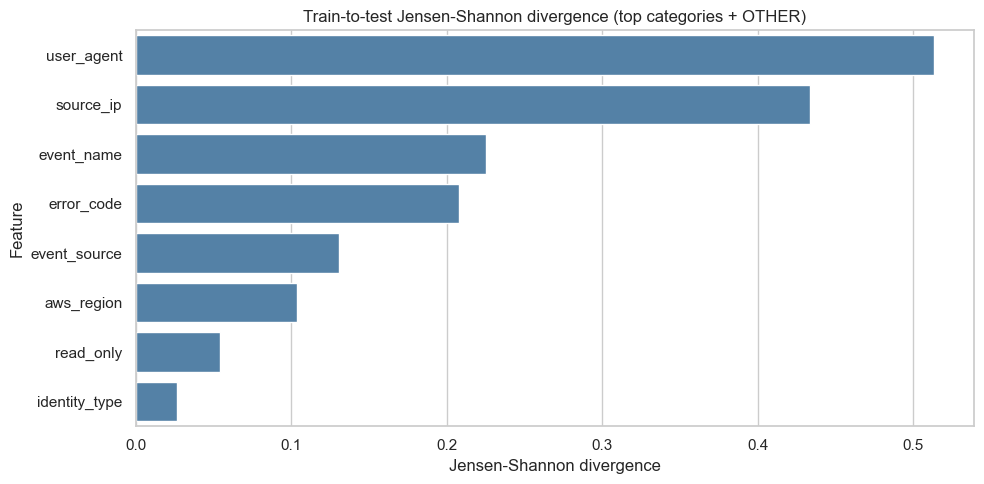

In [29]:
def categorical_jsd(
    con,
    column: str,
    train_end,
    valid_end,
    top_k: int = 100
) -> float:
    """
    Calculate Jensen-Shannon divergence between the training and test
    distributions of a categorical feature.
    """

    # Validate the dynamic column name before inserting it into SQL.
    available_columns = set(
        con.execute("DESCRIBE events").df()["column_name"]
    )

    if column not in available_columns:
        raise ValueError(
            f"Unknown column: {column!r}. "
            f"Available columns: {sorted(available_columns)}"
        )

    if top_k <= 0:
        raise ValueError("top_k must be greater than zero.")

    # Quote the validated identifier.
    quoted_column = '"' + column.replace('"', '""') + '"'

    query = f"""
    WITH labeled AS (
        SELECT
            CASE
                WHEN event_time < $1 THEN 'train'
                WHEN event_time >= $2 THEN 'test'
                ELSE NULL
            END AS split_name,

            COALESCE(
                CAST({quoted_column} AS VARCHAR),
                '<NULL>'
            ) AS category_value

        FROM events
    ),

    top_categories AS (
        SELECT category_value
        FROM labeled
        WHERE split_name = 'train'
        GROUP BY category_value
        ORDER BY COUNT(*) DESC
        LIMIT {int(top_k)}
    ),

    bucketed AS (
        SELECT
            split_name,
            CASE
                WHEN category_value IN (
                    SELECT category_value
                    FROM top_categories
                )
                THEN category_value
                ELSE '<OTHER>'
            END AS category_value
        FROM labeled
        WHERE split_name IS NOT NULL
    ),

    category_counts AS (
        SELECT
            split_name,
            category_value,
            COUNT(*)::DOUBLE AS n
        FROM bucketed
        GROUP BY split_name, category_value
    ),

    probabilities AS (
        SELECT
            split_name,
            category_value,
            n / SUM(n) OVER (
                PARTITION BY split_name
            ) AS probability
        FROM category_counts
    )

    SELECT *
    FROM probabilities
    """

    # Parameterized timestamps avoid timestamp formatting problems.
    result = con.execute(
        query,
        [train_end, valid_end]
    ).df()

    if result.empty:
        return np.nan

    distribution = (
        result.pivot(
            index="category_value",
            columns="split_name",
            values="probability"
        )
        .fillna(0.0)
    )

    p = distribution.get(
        "train",
        pd.Series(0.0, index=distribution.index)
    ).to_numpy(dtype=float)

    q = distribution.get(
        "test",
        pd.Series(0.0, index=distribution.index)
    ).to_numpy(dtype=float)

    if p.sum() == 0 or q.sum() == 0:
        return np.nan

    midpoint = (p + q) / 2.0

    train_mask = p > 0
    test_mask = q > 0

    jsd = (
        0.5 * np.sum(
            p[train_mask]
            * np.log2(p[train_mask] / midpoint[train_mask])
        )
        +
        0.5 * np.sum(
            q[test_mask]
            * np.log2(q[test_mask] / midpoint[test_mask])
        )
    )

    return float(jsd)


drift_columns = [
    "event_source",
    "event_name",
    "aws_region",
    "identity_type",
    "user_agent",
    "source_ip",
    "error_code",
    "read_only"
]

drift = pd.DataFrame({
    "feature": drift_columns,
    "train_test_JSD": [
        categorical_jsd(
            con,
            column,
            train_end,
            valid_end,
            top_k=100
        )
        for column in drift_columns
    ]
}).sort_values(
    "train_test_JSD",
    ascending=False
)

display(drift)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=drift,
    y="feature",
    x="train_test_JSD",
    color="steelblue"
)

plt.title(
    "Train-to-test Jensen-Shannon divergence "
    "(top categories + OTHER)"
)
plt.xlabel("Jensen-Shannon divergence")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 18. Candidate event-level feature table for XGBoost

In [30]:
feature_output_path = OUTPUT_DIR/'xgboost_candidate_features.parquet'
if feature_output_path.exists(): feature_output_path.unlink()
feature_sql = f'''
COPY (
WITH stats AS (
 SELECT event_name, count(*) AS api_global_count, count(DISTINCT actor_id) AS api_actor_count FROM events GROUP BY event_name
), actor_stats AS (
 SELECT actor_id, min(event_time) actor_first_seen, count(*) actor_total_events, count(DISTINCT event_name) actor_api_diversity FROM events GROUP BY actor_id
), window_stats AS (
 SELECT time_bucket(INTERVAL '5 minutes', event_time) w5, actor_id, count(*) events_actor_5m, count_if(error_code IS NOT NULL) errors_actor_5m, count(DISTINCT event_name) apis_actor_5m
 FROM events GROUP BY ALL
)
SELECT e.event_id, e.event_time,
 CASE WHEN e.event_time < TIMESTAMP '{train_end}' THEN 'train' WHEN e.event_time < TIMESTAMP '{valid_end}' THEN 'validation' ELSE 'test' END data_split,
 e.event_source, e.event_name, e.aws_region, e.identity_type, e.ua_family, e.read_only, e.management_event,
 hour(e.event_time) hour_utc, dayofweek(e.event_time) day_of_week_utc, month(e.event_time) month_utc,
 (dayofweek(e.event_time) IN (0,6))::INT is_weekend_utc, (e.error_code IS NOT NULL)::INT has_error,
 ln(1+s.api_global_count) log_api_global_count, s.api_actor_count,
 date_diff('second',a.actor_first_seen,e.event_time) actor_tenure_seconds, ln(1+a.actor_total_events) log_actor_total_events, a.actor_api_diversity,
 w.events_actor_5m, w.errors_actor_5m, w.apis_actor_5m
FROM events_enriched e JOIN stats s USING(event_name) JOIN actor_stats a USING(actor_id)
JOIN window_stats w ON w.actor_id=e.actor_id AND w.w5=time_bucket(INTERVAL '5 minutes',e.event_time)
) TO '{str(OUTPUT_DIR/'xgboost_candidate_features.parquet').replace("'", "''")}' (FORMAT PARQUET, COMPRESSION ZSTD)
'''
con.execute(feature_sql)
feature_preview = pd.read_parquet(OUTPUT_DIR/'xgboost_candidate_features.parquet').head(20)
display(feature_preview); print('Feature artifact MiB:', round((OUTPUT_DIR/'xgboost_candidate_features.parquet').stat().st_size/2**20,2))

,event_id,event_time,data_split,event_source,event_name,aws_region,identity_type,ua_family,read_only,management_event,hour_utc,day_of_week_utc,month_utc,is_weekend_utc,has_error,log_api_global_count,api_actor_count,actor_tenure_seconds,log_actor_total_events,actor_api_diversity,events_actor_5m,errors_actor_5m,apis_actor_5m
0,1e63810-9286-4088-86d6-f932109f8ef9,2019-08-22 02:23:20+00:00,train,ec2.amazonaws.com,RunInstances,eu-west-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,79506488,13.727591,1041,554,554.0,1
1,f8b9ea49-31d8-4d9a-bd98-159376634348,2019-08-22 02:23:21+00:00,train,ec2.amazonaws.com,RunInstances,ap-south-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289788,13.715782,910,1696,1666.0,9
2,ffb777ed-2c19-4dc7-9122-90bdf6e6525c,2019-08-22 02:23:21+00:00,train,ec2.amazonaws.com,RunInstances,eu-west-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289788,13.715782,910,1696,1666.0,9
3,4681df46-6e24-42d4-8978-970236e30bfa9,2019-08-22 02:23:21+00:00,train,ec2.amazonaws.com,RunInstances,us-east-2,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289788,13.715782,910,1696,1666.0,9
4,f8b9ea49-31d8-4d9a-bd98-159376634348,2019-08-22 02:23:21+00:00,train,ec2.amazonaws.com,RunInstances,ap-south-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289788,13.715782,910,1696,1666.0,9
5,ffb777ed-2c19-4dc7-9122-90bdf6e6525c,2019-08-22 02:23:21+00:00,train,ec2.amazonaws.com,RunInstances,eu-west-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289788,13.715782,910,1696,1666.0,9
6,4681df46-6e24-42d4-8978-970236e30bfa9,2019-08-22 02:23:21+00:00,train,ec2.amazonaws.com,RunInstances,us-east-2,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289788,13.715782,910,1696,1666.0,9
7,41ccd551-730b-4d79-9448-7b1e4086f04b,2019-08-22 02:23:22+00:00,train,ec2.amazonaws.com,RunInstances,ap-south-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289789,13.715782,910,1696,1666.0,9
8,4c78a94f-77a7-43ec-b74e-5e2a561d618a,2019-08-22 02:23:22+00:00,train,ec2.amazonaws.com,RunInstances,ap-southeast-2,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,78289789,13.715782,910,1696,1666.0,9
9,42c68211-0c11-4fd3-ba20-6b11cb1069b3,2019-08-22 02:23:22+00:00,train,ec2.amazonaws.com,RunInstances,eu-west-1,IAMUser,boto,None,None,7,4,8,0,1,14.095493,4,79506490,13.727591,1041,554,554.0,1


Feature artifact MiB: 32.92


## 19. Bias, privacy, validity, and threat-model checklist

- **Selection bias:** flAWS is an intentionally vulnerable training environment, not a random sample of enterprise AWS activity.
- **Coverage bias:** no S3/Lambda object-level data events; API calls unsupported by CloudTrail at collection time are absent.
- **Temporal bias:** AWS services, APIs, clients, and attacker techniques changed between 2017 and 2020.
- **Exposure bias:** publicly documented CTF paths can overrepresent specific reconnaissance and exploitation behavior.
- **Anonymization effects:** IP/account substitutions break geolocation, ASN, reputation, and some cross-record semantics.
- **Entity ambiguity:** actor fallback keys can merge shared IPs or split rotating credentials.
- **Label bias:** rule-based labels reflect the authors' detection policy and can encode circular reasoning.
- **Class imbalance:** report PR-AUC, recall at a fixed analyst-review budget, false positives per day, calibration, and cost-weighted utility—not accuracy alone.
- **Privacy/security:** logs represent user and attacker behavior. Restrict access, encrypt storage, redact residual identifiers, and never publish sensitive request/response payloads without review.
- **Deployment validity:** a model trained on this archive is a research prototype; it should not autonomously block production actions.

## 20. Export evidence and reproducibility manifest

In [31]:
run_manifest = {
 'created_utc': dt.datetime.now(dt.timezone.utc).isoformat(), 'data_url': DATA_URL,
 'archive_path': str(ARCHIVE_PATH.resolve()), 'archive_bytes': ARCHIVE_PATH.stat().st_size, 'archive_md5': archive_md5,
 'quick_mode': QUICK_MODE, 'selected_files': [str(p.relative_to(RAW_DIR)) for p in analysis_files],
 'parsed_events': int(overview.loc[0,'events']), 'start_time': str(overview.loc[0,'start_time']), 'end_time': str(overview.loc[0,'end_time']),
 'train_end': str(train_end), 'validation_end': str(valid_end),
 'versions': {'python': platform.python_version(), 'pandas': pd.__version__, 'pyarrow': pa.__version__, 'duckdb': duckdb.__version__},
 'outputs': [str(p) for p in sorted(OUTPUT_DIR.glob('*'))]
}
(OUTPUT_DIR/'run_manifest.json').write_text(json.dumps(run_manifest, indent=2), encoding='utf-8')
file_inventory.to_csv(OUTPUT_DIR/'source_file_inventory.csv', index=False)
missingness.to_csv(OUTPUT_DIR/'missingness_and_cardinality.csv', index=False)
service_counts.to_csv(OUTPUT_DIR/'service_summary.csv', index=False)
api_counts.to_csv(OUTPUT_DIR/'api_summary.csv', index=False)
actor_profiles.to_parquet(OUTPUT_DIR/'actor_profiles.parquet', index=False)
drift.to_csv(OUTPUT_DIR/'temporal_drift_jsd.csv', index=False)
display(run_manifest)

{'created_utc': '2026-09-19T07:15:39.456316+00:00',
 'data_url': 'https://summitroute.com/downloads/flaws_cloudtrail_logs.tar',
 'archive_path': 'E:\\Trash\\MLOPS\\cloudtrail_eda_workspace\\downloads\\flaws_cloudtrail_logs.tar',
 'archive_bytes': 251688960,
 'archive_md5': '4f0481c6be700ffc7610dbbf8cee5578',
 'quick_mode': False,
 'selected_files': ['flaws_cloudtrail_logs\\flaws_cloudtrail00.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail01.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail02.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail03.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail04.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail05.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail06.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail07.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail08.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail09.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail10.json.gz',
  'flaws_cloudtrail_logs\\flaws_cloudtrail11.

## 21. Final research decisions before model training

1. Have at least two analysts label a stratified sample containing rule hits, anomaly hits, common events, rare events, errors, and time periods?
2. Is inter-rater agreement reported and are disagreements adjudicated?
3. Is the label definition operationally precise, with an observation window and severity policy?
4. Are train/validation/test boundaries frozen before tuning?
5. Are exact duplicates, near-duplicates, recurring sessions, and actor overlap audited across splits?
6. Is a rule-only baseline compared with XGBoost, and are leakage-prone features ablated?
7. Are PR-AUC, calibration, recall at review capacity, false positives/day, subgroup/time-slice metrics, and bootstrap confidence intervals reported?
8. Is threshold selection based only on validation data and explicit incident-review costs?
9. Is drift monitored for feature distributions, missingness, category novelty, prediction scores, calibration, and delayed labels?
10. Can every prediction be traced to the immutable data version, feature code, model artifact, threshold, and explanation?

Only after these decisions should the XGBoost training and SageMaker deployment notebooks be treated as confirmatory rather than exploratory work.

In [32]:
try:
    con.close()
    print("DuckDB connection closed.")
except NameError:
    print("No connection named 'con' exists.")

DuckDB connection closed.
